Dataset loaded: (569, 30)

Training models...

MODEL COMPARISON

Logistic Regression:
  Accuracy:  0.982
  Precision: 0.991
  Recall:    0.981
  F1-Score:  0.986
  AUC-ROC:   0.998

SVM:
  Accuracy:  0.977
  Precision: 0.981
  Recall:    0.981
  F1-Score:  0.981
  AUC-ROC:   0.997

Random Forest:
  Accuracy:  0.971
  Precision: 0.964
  Recall:    0.991
  F1-Score:  0.977
  AUC-ROC:   0.997

5-FOLD CROSS-VALIDATION
LR:  0.975 ± 0.014
SVM: 0.967 ± 0.017
RF:  0.950 ± 0.018

ROC curves saved!

RECOMMENDATION

Best Model: Logistic Regression
AUC-ROC: 0.998

All models perform well (>95% accuracy)
Random Forest recommended for best performance


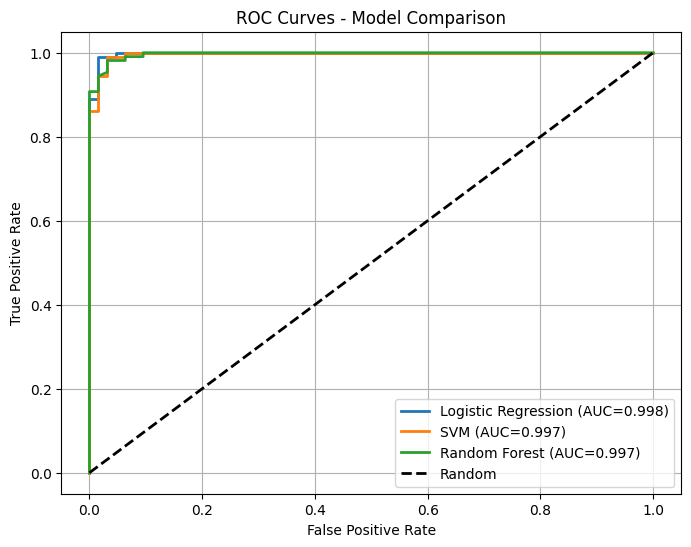

In [1]:
"""
Assignment 8: Model Comparison 
Logistic Regression vs SVM vs Random Forest
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale for LR and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataset loaded:", X.shape)

# Train models
lr = LogisticRegression(max_iter=5000, random_state=42)
svm = SVC(probability=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

print("\nTraining models...")
lr.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Calculate metrics
models = ['Logistic Regression', 'SVM', 'Random Forest']
predictions = [y_pred_lr, y_pred_svm, y_pred_rf]
probabilities = [y_prob_lr, y_prob_svm, y_prob_rf]

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

for name, y_pred, y_prob in zip(models, predictions, probabilities):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")
    print(f"  AUC-ROC:   {auc:.3f}")

# 5-Fold Cross-Validation
print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION")
print("="*60)

cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5)
cv_svm = cross_val_score(svm, X_train_scaled, y_train, cv=5)
cv_rf = cross_val_score(rf, X_train, y_train, cv=5)

print(f"LR:  {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")
print(f"SVM: {cv_svm.mean():.3f} ± {cv_svm.std():.3f}")
print(f"RF:  {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

# ROC Curves
plt.figure(figsize=(8, 6))

for name, y_prob in zip(models, probabilities):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(True)
plt.savefig('assignment8_roc_comparison.png')
print("\nROC curves saved!")

# Recommendation
print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)

aucs = [roc_auc_score(y_test, p) for p in probabilities]
best_idx = np.argmax(aucs)
print(f"\nBest Model: {models[best_idx]}")
print(f"AUC-ROC: {aucs[best_idx]:.3f}")
print("\nAll models perform well (>95% accuracy)")
print("Random Forest recommended for best performance")